In [1]:
# !pip install pandas numpy scikit-learn nltk seaborn matplotlib

All Imports

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import pickle
import nltk
nltk.download("stopwords")

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import accuracy_score, classification_report

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading dataset (WELFake_Dataset.csv)

In [3]:
df = pd.read_csv('/content/sample_data/WELFake_Dataset.csv')
df.head(10)

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
5,5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1
6,6,DR BEN CARSON TARGETED BY THE IRS: “I never ha...,DR. BEN CARSON TELLS THE STORY OF WHAT HAPPENE...,1
7,7,HOUSE INTEL CHAIR On Trump-Russia Fake Story: ...,,1
8,8,Sports Bar Owner Bans NFL Games…Will Show Only...,"The owner of the Ringling Bar, located south o...",1
9,9,Latest Pipeline Leak Underscores Dangers Of Da...,"FILE – In this Sept. 15, 2005 file photo, the ...",1


# **EDA**

In [4]:
df.drop(["Unnamed: 0"], axis=1, inplace=True)

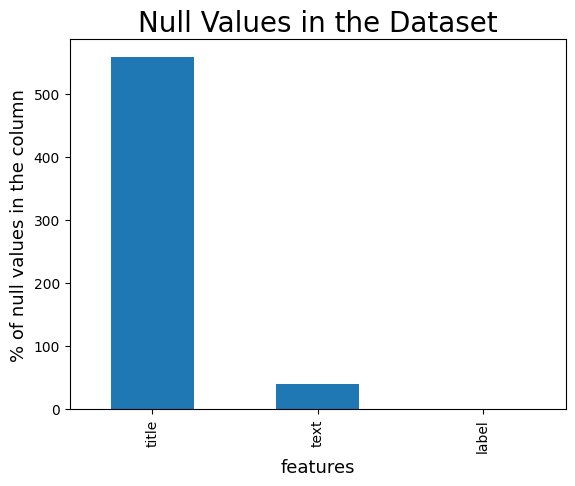

In [5]:
df.isnull().sum().plot(kind="bar")
plt.title("Null Values in the Dataset",fontsize=20)
plt.xlabel('features',fontsize=13)
plt.ylabel('% of null values in the column',fontsize=13)
plt.show()

In [6]:
df.isnull().sum()

,0
title,558
text,39
label,0


In [7]:
df.dropna(axis=0,inplace=True)

In [8]:
df.isnull().sum()

,0
title,0
text,0
label,0


In [9]:
df.nunique()

,0
title,62308
text,62200
label,2


In [10]:
df.duplicated().sum()

np.int64(8416)

In [11]:
df.drop_duplicates(inplace=True)
df.shape

(63121, 3)

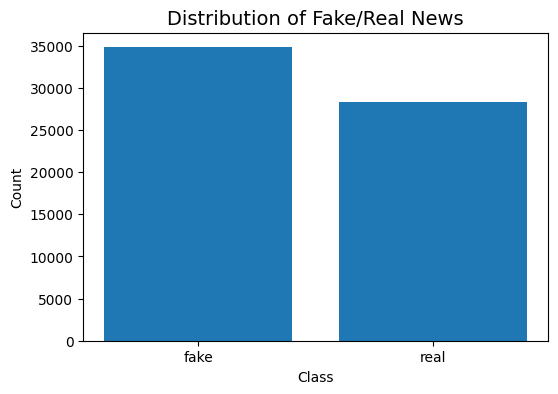

In [12]:
class_names = ['fake', 'real']
label_count = df.label.value_counts()

plt.figure(figsize=(6,4))
plt.bar(label_count.index, label_count.values)

plt.xticks(label_count.index, class_names)

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Distribution of Fake/Real News", fontsize=14)

plt.show()

In [13]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


In [14]:
df['title'] = df['title']
df['text'] = df['text']

df['content'] = df['title'] + " " + df['text']
df['content'] = df['content'].apply(clean_text)

X = df['content']
y = df['label']  # 0 = real, 1 = fake (or your dataset encoding)

Splitting the data for training and testing

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
stop_words = stopwords.words("english")

tfidf = TfidfVectorizer(
    stop_words=stop_words,
    max_features=50000,
    ngram_range=(1, 2)
)

In [17]:
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# **Logistic Regression**

In [18]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=400)
log_model.fit(X_train_vec, y_train)
log_pred = log_model.predict(X_test_vec)
log_acc = accuracy_score(y_test, log_pred)
print("\nLogistic Regression Accuracy:", log_acc)


Logistic Regression Accuracy: 0.9539801980198019


# **SVM (Linear)**

In [19]:
from sklearn.svm import LinearSVC
svm_model = LinearSVC()
svm_model.fit(X_train_vec, y_train)
svm_pred = svm_model.predict(X_test_vec)
svm_acc = accuracy_score(y_test, svm_pred)
print("Linear SVM Accuracy:", svm_acc)

Linear SVM Accuracy: 0.9642772277227722


#  **Naive Bayes**

In [20]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
nb_pred = nb_model.predict(X_test_vec)
nb_acc = accuracy_score(y_test, nb_pred)
print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.8777821782178218


# **Random Forest**

In [34]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train_vec, y_train)
rf_pred = rf_model.predict(X_test_vec)
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9399603960396039


In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Linear SVM (LinearSVC)": LinearSVC(),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

# Store CV scores
cv_scores = {}

print("\nRunning 5-Fold Cross Validation...\n")

for name, model in models.items():
    scores = cross_val_score(model, X_train_vec, y_train, cv=5, scoring='accuracy')
    cv_scores[name] = scores
    print(f"{name}: {scores.mean():.4f}  (std: {scores.std():.4f})")

# Best model selection
best_model_name = max(cv_scores, key=lambda m: cv_scores[m].mean())
print("\nBest Model Based on CV Accuracy:", best_model_name)


Running 5-Fold Cross Validation...

Logistic Regression: 0.9495  (std: 0.0018)
Linear SVM (LinearSVC): 0.9632  (std: 0.0011)
Naive Bayes: 0.8786  (std: 0.0032)
Random Forest: 0.9359  (std: 0.0010)

Best Model Based on CV Accuracy: Linear SVM (LinearSVC)


In [35]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Define models
models = {
    "Logistic Regression": log_model,
    "SVM": svm_model,
    "Naive Bayes": nb_model,
    "Random Forest": rf_model
}

# Create Stratified K-Fold object
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store CV results
cv_scores = {}

print("\nRunning Stratified 5-Fold Cross Validation...\n")

for name, model in models.items():
    scores = cross_val_score(model, X_train_vec, y_train, cv=skf, scoring='accuracy')
    cv_scores[name] = scores
    print(f"{name}: {scores.mean():.4f}  (std: {scores.std():.4f})")

# Best model selection
best_model_name = max(cv_scores, key=lambda m: cv_scores[m].mean())
print("\nBest Model Based on CV Accuracy:", best_model_name)



Running Stratified 5-Fold Cross Validation...

Logistic Regression: 0.9493  (std: 0.0018)
SVM: 0.9632  (std: 0.0016)
Naive Bayes: 0.8782  (std: 0.0019)


KeyboardInterrupt: 

In [36]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_score, recall_score

predictions = {}
metrics = {"Accuracy": [], "Precision": [], "Recall": []}

for name, model in models.items():
    y_pred = model.predict(X_test_vec)
    predictions[name] = y_pred

    # Metrics
    metrics["Accuracy"].append(accuracy_score(y_test, y_pred))
    metrics["Precision"].append(precision_score(y_test, y_pred))
    metrics["Recall"].append(recall_score(y_test, y_pred))

In [44]:
data = []
for i, model in enumerate(models.keys()):
    data.append({"Metric": "Accuracy", "Model": model, "Score": metrics["Accuracy"][i]})
    data.append({"Metric": "Precision", "Model": model, "Score": metrics["Precision"][i]})
    data.append({"Metric": "Recall", "Model": model, "Score": metrics["Recall"][i]})

df_metrics = pd.DataFrame(data)

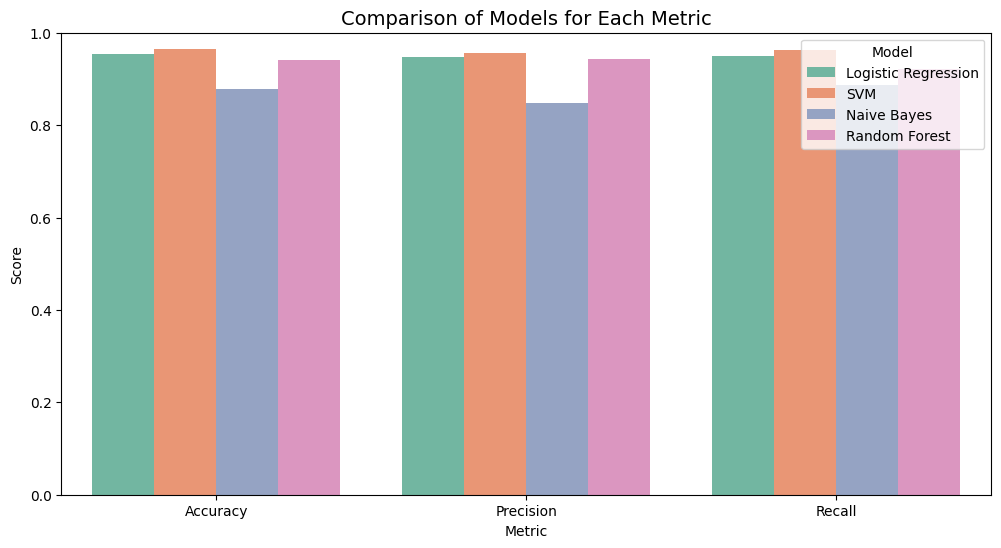

In [45]:
plt.figure(figsize=(12,6))
sns.barplot(x="Metric", y="Score", hue="Model", data=df_metrics, palette="Set2")
plt.ylim(0,1)
plt.title("Comparison of Models for Each Metric", fontsize=14)
plt.ylabel("Score")
plt.xlabel("Metric")
plt.legend(title="Model")
plt.show()

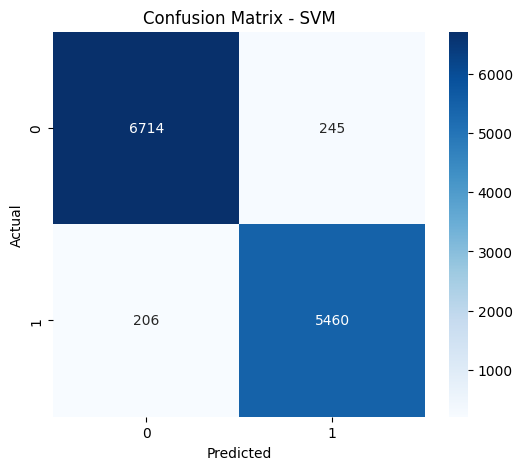

In [39]:
best_model_name = max(models.keys(), key=lambda name: metrics["Accuracy"][list(models.keys()).index(name)])
best_y_pred = predictions[best_model_name]

# Confusion Matrix
cm = confusion_matrix(y_test, predictions[best_model_name])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [40]:
print("Classification Report - SVM")
print(classification_report(y_test, svm_pred, target_names=["REAL", "FAKE"]))

Classification Report - SVM
              precision    recall  f1-score   support

        REAL       0.97      0.96      0.97      6959
        FAKE       0.96      0.96      0.96      5666

    accuracy                           0.96     12625
   macro avg       0.96      0.96      0.96     12625
weighted avg       0.96      0.96      0.96     12625



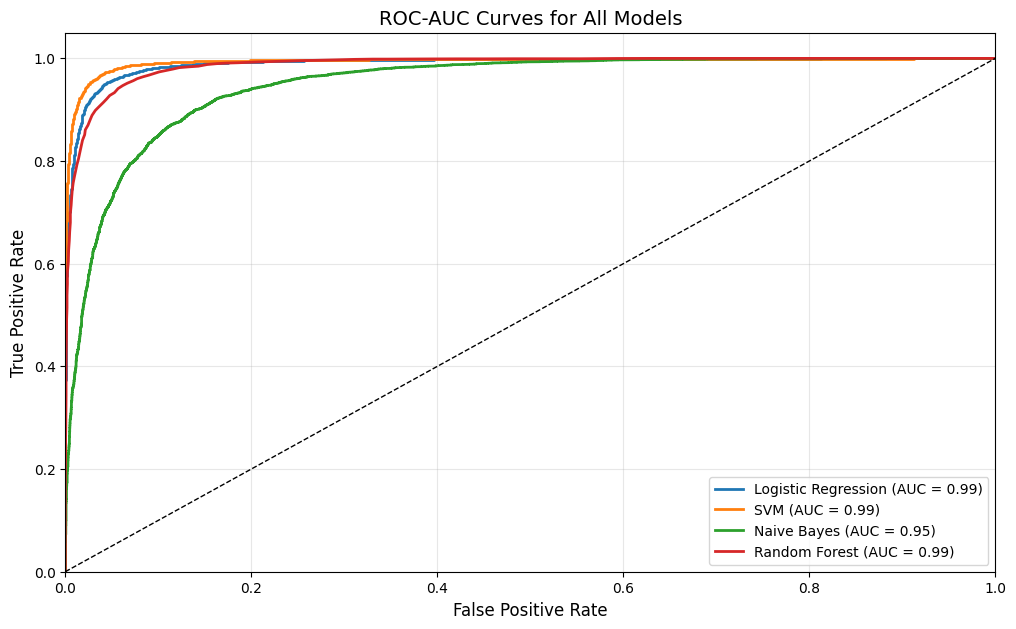

In [47]:
plt.figure(figsize=(12,7))

for name, model in models.items():
    try:
        y_score = model.predict_proba(X_test_vec)[:, 1]  # Probability for positive class (FAKE)
    except AttributeError:
        # For models like SVM without predict_proba
        y_score = model.decision_function(X_test_vec)
        y_score = 1 / (1 + np.exp(-y_score))  # Convert to pseudo-probability

    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {roc_auc:.2f})")

# Diagonal line for random classifier
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC-AUC Curves for All Models", fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()

In [48]:
best_model = models[best_model_name]

def predict_news(text):
    text = clean_text(text)
    vector = tfidf.transform([text])
    pred = best_model.predict(vector)[0]

    # Calculate confidence
    try:
        conf = best_model.predict_proba(vector)[0][pred]
    except AttributeError:
        score = best_model.decision_function(vector)[0]
        conf = 1 / (1 + np.exp(-score))
        if pred == 0:
            conf = 1 - conf

    return {
        "label": "FAKE NEWS" if pred == 1 else "REAL NEWS",
        "model_used": best_model_name,
        "confidence": round(conf, 4)
    }


In [49]:
sample = "Breaking news: Chocolate cures cancer!"
print(predict_news(sample))

{'label': 'FAKE NEWS', 'model_used': 'SVM', 'confidence': np.float64(0.9222)}
